# NBA Lineup Predictor Demo

Goal: enter any two player groups and get a win probability plus an explanation.

This demo reads the latest model outputs from disk. The headline metrics are computed from `outputs/predictions_test.csv`, and model metadata is read from `outputs/final_weights.json`.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from math import exp

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, roc_auc_score

from predict_lineup import predict_matchup, find_player, summary_table

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.unicode_minus'] = False

preds = pd.read_csv('outputs/predictions_test.csv')
with open('outputs/final_weights.json') as f:
    weights = json.load(f)

auc = roc_auc_score(preds['home_win'], preds['P_home_win'])
accuracy = accuracy_score(preds['home_win'], preds['pred_home_win'])

metrics = pd.DataFrame([
    {'Metric': 'Test AUC', 'Value': auc},
    {'Metric': 'Test Accuracy', 'Value': accuracy},
    {'Metric': 'Train matchups used by final layer', 'Value': weights['n_train_matchups']},
    {'Metric': 'Test matchups', 'Value': weights['n_test_matchups']},
    {'Metric': 'Output B L1 survivors', 'Value': f"{weights['output_B_l1_kept_features']} / {weights['output_B_total_features']}"},
    {'Metric': 'Output C L1 survivors', 'Value': f"{weights['output_C_l1_kept_features']} / {weights['output_C_total_features']}"},
])

display(metrics)


,Metric,Value
0,Test AUC,0.727991
1,Test Accuracy,0.675918
2,Train matchups used by final layer,3935
3,Test matchups,1225
4,Output B L1 survivors,13 / 54
5,Output C L1 survivors,31 / 81


## 1. Case A — Lakers vs Celtics at a 2025-03-01 Snapshot


In [2]:
home_names = ['LeBron James', 'Anthony Davis', 'Austin Reaves',
              "D'Angelo Russell", 'Rui Hachimura']
away_names = ['Jayson Tatum', 'Jaylen Brown', 'Jrue Holiday',
              'Derrick White', 'Porzingis']

home_ids = [find_player(n) for n in home_names]
away_ids = [find_player(n) for n in away_names]

result = predict_matchup(home_ids, away_ids, snapshot_date='2025-03-01')

case_a = pd.DataFrame([{
    'Snapshot date': result['snapshot_date'],
    'P80 season': result['season_for_p80'],
    'P(home wins)': result['P_home_win'],
    'P(away wins)': result['P_away_win'],
}])

display(case_a.round(3))
display(summary_table(result).round(3))


,Snapshot date,P80 season,P(home wins),P(away wins)
0,2025-03-01,2024-25,0.594,0.406


,P_home_win,Score_A_home,Score_A_away,ΔA_z,Score_B_home,Score_B_away,ΔB_z,Score_C_z,pm_home,pm_away,Δpm_z
0,0.594,0.865,0.683,0.123,0.153,0.092,0.143,-1.297,5.38,4.92,0.111


In [3]:
# Additive logit explanation: each row is read from the model result.
contrib = pd.Series(result['logit_contributions'], name='Contribution to logit')
logit_sum = contrib.sum()
probability_from_logit = 1 / (1 + exp(-logit_sum))

logit_check = pd.DataFrame([
    {'Quantity': 'Sum of logit contributions', 'Value': logit_sum},
    {'Quantity': 'Sigmoid(logit sum)', 'Value': probability_from_logit},
    {'Quantity': 'Model P(home wins)', 'Value': result['P_home_win']},
])

display(logit_check.round(4))
display(contrib.to_frame().round(4))


,Quantity,Value
0,Sum of logit contributions,0.3824
1,Sigmoid(logit sum),0.5945
2,Model P(home wins),0.5945


,Contribution to logit
from_delta_A,0.0231
from_delta_B,0.0258
from_score_C,0.0232
from_delta_pm,0.0533
from_is_home,0.1280
from_intercept,0.1290


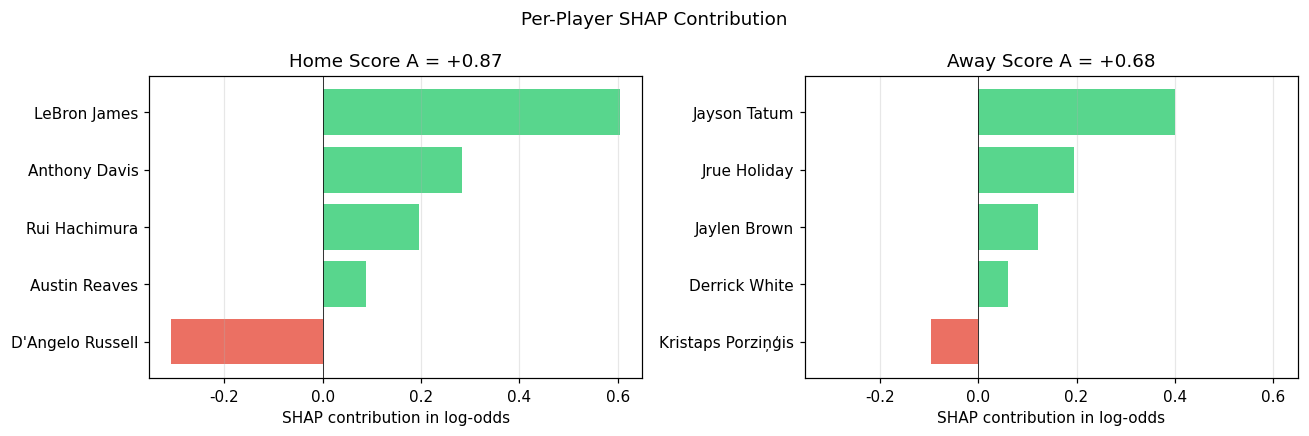

In [4]:
# Visualization: per-player SHAP contributions for both teams.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for ax, side_df, title in [
    (axes[0], result['per_player_shap_home'], f'Home Score A = {result["score_A_home"]:+.2f}'),
    (axes[1], result['per_player_shap_away'], f'Away Score A = {result["score_A_away"]:+.2f}'),
]:
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in side_df['shap_sum']]
    ax.barh(side_df['player_name'], side_df['shap_sum'], color=colors, alpha=0.8)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(title)
    ax.set_xlabel('SHAP contribution in log-odds')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Per-Player SHAP Contribution')
fig.tight_layout()


## 2. Model Spread Check — Strong Team vs Weak Team

Case A can be close because both teams are strong. To show that the model is not stuck near 50%, compare Oklahoma City against Washington using the same snapshot date.


In [5]:
okc = ['Shai Gilgeous-Alexander', 'Jalen Williams', 'Chet Holmgren',
       'Luguentz Dort', 'Isaiah Hartenstein']
was = ['Jordan Poole', 'Bilal Coulibaly', 'Alex Sarr',
       'Bub Carrington', 'Kyle Kuzma']

result_extreme = predict_matchup(
    [find_player(n) for n in okc],
    [find_player(n) for n in was],
    snapshot_date='2025-03-01',
)

spread_check = pd.DataFrame([
    {
        'Matchup': 'OKC vs WAS',
        'P(home wins)': result_extreme['P_home_win'],
        'delta_A_z': result_extreme['delta_A'],
        'delta_B_z': result_extreme['delta_B'],
        'score_C_z': result_extreme['score_C_z'],
        'delta_pm_z': result_extreme['delta_pm'],
    },
    {
        'Matchup': 'LAL vs BOS',
        'P(home wins)': result['P_home_win'],
        'delta_A_z': result['delta_A'],
        'delta_B_z': result['delta_B'],
        'score_C_z': result['score_C_z'],
        'delta_pm_z': result['delta_pm'],
    },
])

display(spread_check.round(3))


,Matchup,P(home wins),delta_A_z,delta_B_z,score_C_z,delta_pm_z
0,OKC vs WAS,0.830,0.397,0.261,-0.943,2.470
1,LAL vs BOS,0.594,0.123,0.143,-1.297,0.111


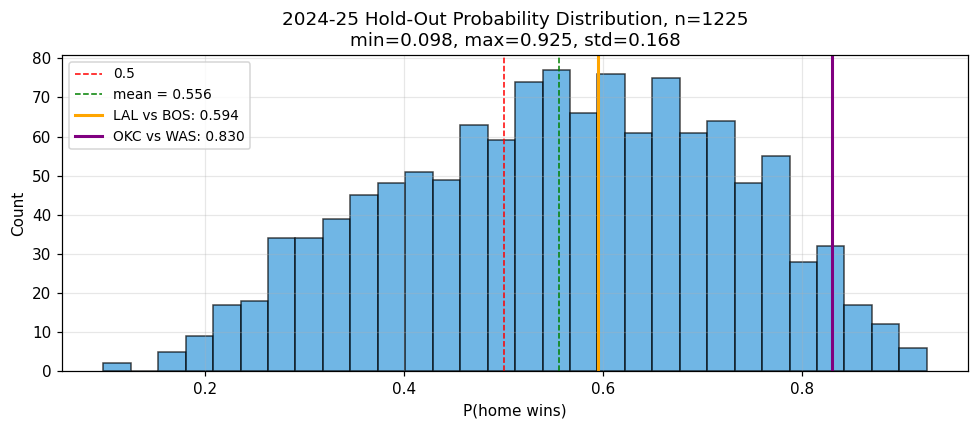

In [6]:
# Distribution of hold-out probabilities, read from the saved prediction file.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(preds['P_home_win'], bins=30, edgecolor='black', alpha=0.7, color='#3498db')
ax.axvline(0.5, color='red', ls='--', lw=1, label='0.5')
ax.axvline(preds['P_home_win'].mean(), color='green', ls='--', lw=1,
           label=f'mean = {preds["P_home_win"].mean():.3f}')
ax.axvline(result['P_home_win'], color='orange', lw=2,
           label=f'LAL vs BOS: {result["P_home_win"]:.3f}')
ax.axvline(result_extreme['P_home_win'], color='purple', lw=2,
           label=f'OKC vs WAS: {result_extreme["P_home_win"]:.3f}')

ax.set_xlabel('P(home wins)')
ax.set_ylabel('Count')
ax.set_title(
    f'2024-25 Hold-Out Probability Distribution, n={len(preds)}\n'
    f'min={preds["P_home_win"].min():.3f}, max={preds["P_home_win"].max():.3f}, '
    f'std={preds["P_home_win"].std():.3f}'
)
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()


## 3. Case B — Player Swap What-If

Replace LeBron James with Luka Doncic and compare the prediction.


In [7]:
home_swap = home_names.copy()
home_swap[0] = 'Doncic'

result_swap = predict_matchup(
    [find_player(n) for n in home_swap],
    away_ids,
    snapshot_date='2025-03-01',
)

swap_summary = pd.DataFrame([
    {'Lineup': 'Original lineup', 'P(home wins)': result['P_home_win']},
    {'Lineup': 'LeBron replaced by Doncic', 'P(home wins)': result_swap['P_home_win']},
])
swap_summary['Change vs original'] = swap_summary['P(home wins)'] - result['P_home_win']

display(swap_summary.round(4))

comparison = pd.DataFrame({
    'Original': summary_table(result).iloc[0],
    'Doncic version': summary_table(result_swap).iloc[0],
})
comparison['Difference'] = comparison['Doncic version'] - comparison['Original']
display(comparison.round(3))


,Lineup,P(home wins),Change vs original
0,Original lineup,0.5945,0.0000
1,LeBron replaced by Doncic,0.5622,-0.0323


,Original,Doncic version,Difference
P_home_win,0.594,0.562,-0.032
Score_A_home,0.865,0.444,-0.421
Score_A_away,0.683,0.683,0.000
ΔA_z,0.123,-0.170,-0.292
Score_B_home,0.153,0.078,-0.075
Score_B_away,0.092,0.092,0.000
ΔB_z,0.143,-0.074,-0.216
Score_C_z,-1.297,-1.457,-0.160
pm_home,5.380,4.960,-0.420
pm_away,4.920,4.920,0.000


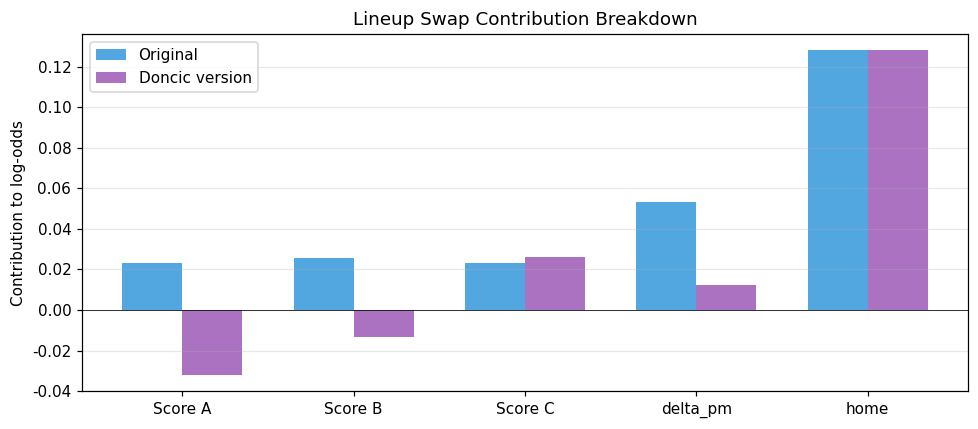

In [8]:
# Visualization: logit contribution changes after the swap.
fig, ax = plt.subplots(figsize=(9, 4))
components = ['from_delta_A', 'from_delta_B', 'from_score_C', 'from_delta_pm', 'from_is_home']
labels = ['Score A', 'Score B', 'Score C', 'delta_pm', 'home']
x = np.arange(len(components))
w = 0.35
ax.bar(x - w/2, [result['logit_contributions'].get(c, 0) for c in components],
       w, label='Original', color='#3498db', alpha=0.85)
ax.bar(x + w/2, [result_swap['logit_contributions'].get(c, 0) for c in components],
       w, label='Doncic version', color='#9b59b6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Contribution to log-odds')
ax.set_title('Lineup Swap Contribution Breakdown')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()


## 4. Case C — Neutral Court and Symmetric Strength Comparison

`is_home=0` removes the home-court feature. `symmetric=True` is different: it uses a forward/reverse logit comparison, which is better for asking which team is stronger on a neutral floor.


In [9]:
result_no_home = predict_matchup(home_ids, away_ids,
                                 snapshot_date='2025-03-01',
                                 is_home=0)
result_symmetric = predict_matchup(home_ids, away_ids,
                                   snapshot_date='2025-03-01',
                                   symmetric=True)
result_swap_symmetric = predict_matchup(away_ids, home_ids,
                                        snapshot_date='2025-03-01',
                                        symmetric=True)

symmetry_check = pd.DataFrame([
    {'Scenario': 'Standard home prediction', 'Probability': result['P_home_win']},
    {'Scenario': 'Home feature removed', 'Probability': result_no_home['P_home_win']},
    {'Scenario': 'Symmetric neutral strength, LAL over BOS', 'Probability': result_symmetric['P_home_win']},
    {'Scenario': 'Symmetric neutral strength, BOS over LAL', 'Probability': result_swap_symmetric['P_home_win']},
    {'Scenario': 'Symmetric pair sum', 'Probability': result_symmetric['P_home_win'] + result_swap_symmetric['P_home_win']},
])

display(symmetry_check.round(4))


,Scenario,Probability
0,Standard home prediction,0.5945
1,Home feature removed,0.5633
2,"Symmetric neutral strength, LAL over BOS",0.5312
3,"Symmetric neutral strength, BOS over LAL",0.4694
4,Symmetric pair sum,1.0006


## 5. Case D — More Than Five Players

The model accepts any number of players because the team features are aggregated by sums, maxes, and means.


In [10]:
home_7 = home_names + ['Max Christie', 'Gabe Vincent']
away_7 = away_names + ['Sam Hauser', 'Payton Pritchard']

result_7 = predict_matchup(
    [find_player(n) for n in home_7],
    [find_player(n) for n in away_7],
    snapshot_date='2025-03-01',
)

size_check = pd.DataFrame([
    {'Lineup size': '5 vs 5', 'P(home wins)': result['P_home_win'], 'Home Score A': result['score_A_home']},
    {'Lineup size': '7 vs 7', 'P(home wins)': result_7['P_home_win'], 'Home Score A': result_7['score_A_home']},
])
size_check['Change in P(home wins)'] = size_check['P(home wins)'] - result['P_home_win']
size_check['Change in Home Score A'] = size_check['Home Score A'] - result['score_A_home']

display(size_check.round(3))
display(result_7['per_player_shap_home'][['player_name', 'min_roll10', 'shap_sum']].round(3))


,Lineup size,P(home wins),Home Score A,Change in P(home wins),Change in Home Score A
0,5 vs 5,0.594,0.865,0.000,0.000
1,7 vs 7,0.543,1.099,-0.052,0.234


,player_name,min_roll10,shap_sum
0,LeBron James,34.96,0.605
1,Anthony Davis,35.31,0.283
2,Max Christie,33.04,0.233
3,Rui Hachimura,35.18,0.196
4,Austin Reaves,34.12,0.088
5,Gabe Vincent,20.68,0.000
6,D'Angelo Russell,25.19,-0.307


## 6. Case E — Historical Snapshot

`snapshot_date` lets us ask the model to use each player's latest rolling stats before a date.

Important caveat: SHAP is context-dependent. A player's SHAP value depends on the lineup and model context, so this is not a clean aging curve.


In [11]:
lal_2021 = ['LeBron James', 'Anthony Davis', 'Dennis Schroder',
            'Kentavious Caldwell-Pope', 'Marc Gasol']

result_2021 = predict_matchup(
    [find_player(n) for n in lal_2021],
    away_ids,
    snapshot_date='2021-04-01',
)

lbj_2021 = result_2021['per_player_shap_home'].query("player_name.str.contains('James')")['shap_sum'].iloc[0]
lbj_2025 = result['per_player_shap_home'].query("player_name.str.contains('James')")['shap_sum'].iloc[0]
ad_2021 = result_2021['per_player_shap_home'].query("player_name=='Anthony Davis'")['shap_sum'].iloc[0]
ad_2025 = result['per_player_shap_home'].query("player_name=='Anthony Davis'")['shap_sum'].iloc[0]

snapshot_check = pd.DataFrame([
    {
        'Scenario': '2020-21 Lakers snapshot',
        'Snapshot date': result_2021['snapshot_date'],
        'P80 season': result_2021['season_for_p80'],
        'P(home wins)': result_2021['P_home_win'],
        'LeBron SHAP': lbj_2021,
        'Anthony Davis SHAP': ad_2021,
    },
    {
        'Scenario': '2024-25 Lakers snapshot',
        'Snapshot date': result['snapshot_date'],
        'P80 season': result['season_for_p80'],
        'P(home wins)': result['P_home_win'],
        'LeBron SHAP': lbj_2025,
        'Anthony Davis SHAP': ad_2025,
    },
])

display(snapshot_check.round(3))


,Scenario,Snapshot date,P80 season,P(home wins),LeBron SHAP,Anthony Davis SHAP
0,2020-21 Lakers snapshot,2021-04-01,2020-21,0.515,0.404,-0.048
1,2024-25 Lakers snapshot,2025-03-01,2024-25,0.594,0.605,0.283


## 7. Key Talking Points

- The model supports arbitrary player groups, not just fixed five-man lineups.
- `Score_A` gives player-level explanations through SHAP.
- `Score_B` summarizes lineup skill coverage and within-team interactions; L1 keeps only 13 of 54 features.
- `Score_C` captures cross-team skill interactions, but its predictive contribution is small.
- `delta_pm` is the strongest single signal because it acts like a recent team-strength prior.
- For neutral strength comparison, use `symmetric=True`; do not rely only on `is_home=0`.
- Calibration diagnostics are saved in `outputs/calibration_buckets.csv` and `outputs/calibration_bucket_045_050.csv`.
